In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter

In [144]:
L =50
k=kb.k_vals(L)

U_0 = kb.U(k,0)



In [209]:
import numpy as np
from scipy.integrate import solve_ivp

def g(t, tau):
    g0= 2
    gf = 0
    return max(g0 + (gf - g0) * t / tau,0)


def rhs(t, v, k,tau): 
  #  print(g(t,tau))
    return [
        2 * ((g(t,tau) - np.cos(k)) * v[0] + np.sin(k) * v[1]) / 1j,
        2 * (-(g(t,tau) - np.cos(k)) * v[1] + np.sin(k) * v[0]) / 1j
    ]

k = kb.k_vals(L)
v_0 = kb.U(k,2)
taus = np.linspace(1,100,20)
x=[ ]
for tau in taus:
    t_span = (0, 300)
    t_eval = np.linspace(*t_span, 500)

    ##Set up empty array
    final_time_evolve = np.empty(np.shape(kb.U(k,100)))

    for i in range(len(k)):
        v0= [v_0[0][i]+0j,v_0[1][i]+0j]
        ki = k[i]
        res = solve_ivp(rhs, t_span, v0, args=(ki,tau), t_eval=t_eval)
        final_time_evolve[0,i]= (res.y[0][-5])
        final_time_evolve[1,i]= (res.y[1][-5])
    x+= [(kb.sigma_general([0,1],kb.U(k,0),k))-(kb.sigma_general([0,1],final_time_evolve,k))]
    print(x[-1])

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4921/1519944217.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  final_time_evolve[0,i]= (res.y[0][-5])
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4921/1519944217.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  final_time_evolve[1,i]= (res.y[1][-5])


0.624004145287379
0.5662101884713314
0.5979828047096568
0.4477491733892969
0.48493526169000145
0.5618710461734275
0.5197332621591366
0.46620950140632844
0.6189804653793323
0.5729453522697628
0.41659415516693143
0.4831353160842289
0.433516342358248
0.5883433604571364
0.5768644949419256
0.558797421763702
0.47041688708822305
0.5411731233167354
0.5494503611580228
0.51858845947559


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


ValueError: x and y must have same first dimension, but have shapes (100,) and (8, 100)

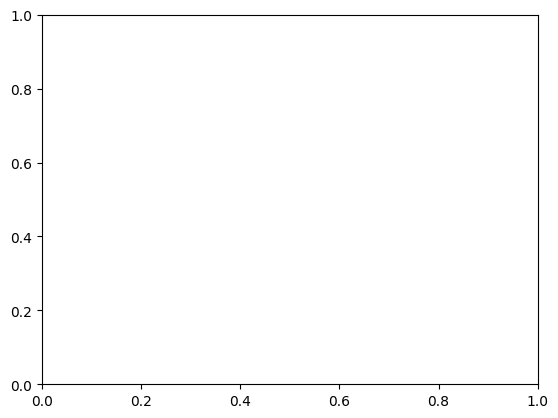

In [247]:
from joblib import Parallel, delayed

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]
taus = np.linspace(1,100,100)
x= np.empty((8,len(taus)))
for tau in taus:
    T = 0
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))

    final_time_evolve = np.array(results).T
    for j in range(8):
        x[j,T]= 1/2-(kb.P_n(j+2,final_time_evolve,k))
    T+=1


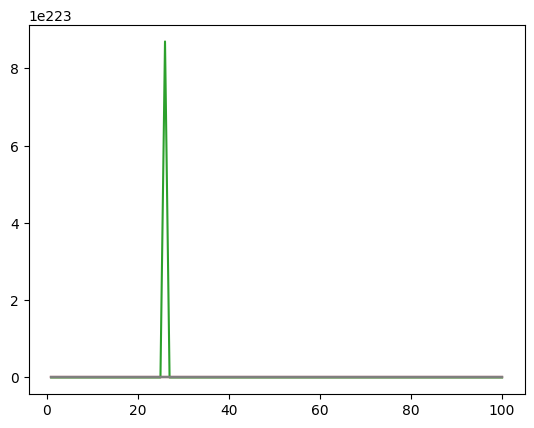

In [248]:
plt.plot(taus,x.T)


In [168]:

ux = []
vy = []
k=kb.k_vals(L)

for n in range(500):
    t = res.t[n]
    gf = g(t,tau)
    U = [kb.U(k,gf)[0][L//2], kb.U(k,gf)[1][L//2]]

    ux.append(U[0])
    vy.append(U[1])

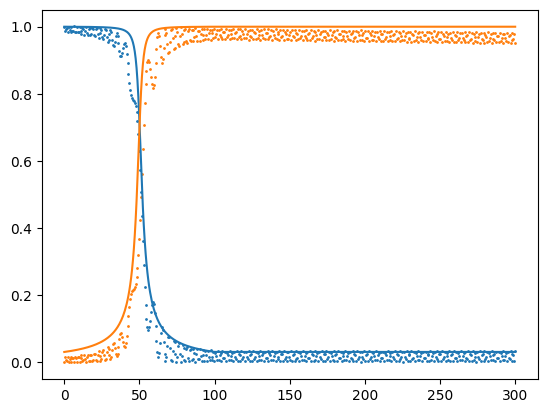

In [169]:
plt.plot(res.t,ux)
plt.plot(res.t,vy)
plt.scatter(res.t,(np.abs(res.y.T)**2)[:,0],s=1)
plt.scatter(res.t,(np.abs(res.y.T)**2)[:,1],s=1)


In [179]:
k=kb.k_vals(L)

np.empty(np.shape(kb.U(k,100)))

array([[ 9.99999952e-01,  9.99999570e-01,  9.99998829e-01,
         9.99997774e-01,  9.99996471e-01,  9.99994999e-01,
         9.99993448e-01,  9.99991914e-01,  9.99990493e-01,
         9.99989274e-01,  9.99988332e-01,  9.99987728e-01,
         9.99987501e-01,  9.99987666e-01,  9.99988215e-01,
         9.99989115e-01,  9.99990308e-01,  9.99991722e-01,
         9.99993266e-01,  9.99994842e-01,  9.99996350e-01,
         9.99997692e-01,  9.99998783e-01,  9.99999552e-01,
         9.99999950e-01,  9.99999950e-01,  9.99999552e-01,
         9.99998783e-01,  9.99997692e-01,  9.99996350e-01,
         9.99994842e-01,  9.99993266e-01,  9.99991722e-01,
         9.99990308e-01,  9.99989115e-01,  9.99988215e-01,
         9.99987666e-01,  9.99987501e-01,  9.99987728e-01,
         9.99988332e-01,  9.99989274e-01,  9.99990493e-01,
         9.99991914e-01,  9.99993448e-01,  9.99994999e-01,
         9.99996471e-01,  9.99997774e-01,  9.99998829e-01,
         9.99999570e-01,  9.99999952e-01],
       [-3.10

In [236]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    plt.scatter(X,dat)
    plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    plt.show()
    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law

